In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
test_df = pd.read_csv('../data/test.csv')
train_df = pd.read_csv('../data/train.csv')

In [131]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [132]:
num_cols = train_df.select_dtypes(np.number).columns
cat_cols = train_df.select_dtypes(object).columns

print('numerical columns')
print(num_cols)
print('cat cols')
print(cat_cols)



numerical columns
Index(['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl',
       'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
       'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat',
       'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')
cat cols
Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')


In [133]:
num_cols= num_cols.drop(labels=['id', 'label'])

cat_cols = cat_cols.union(['label'])

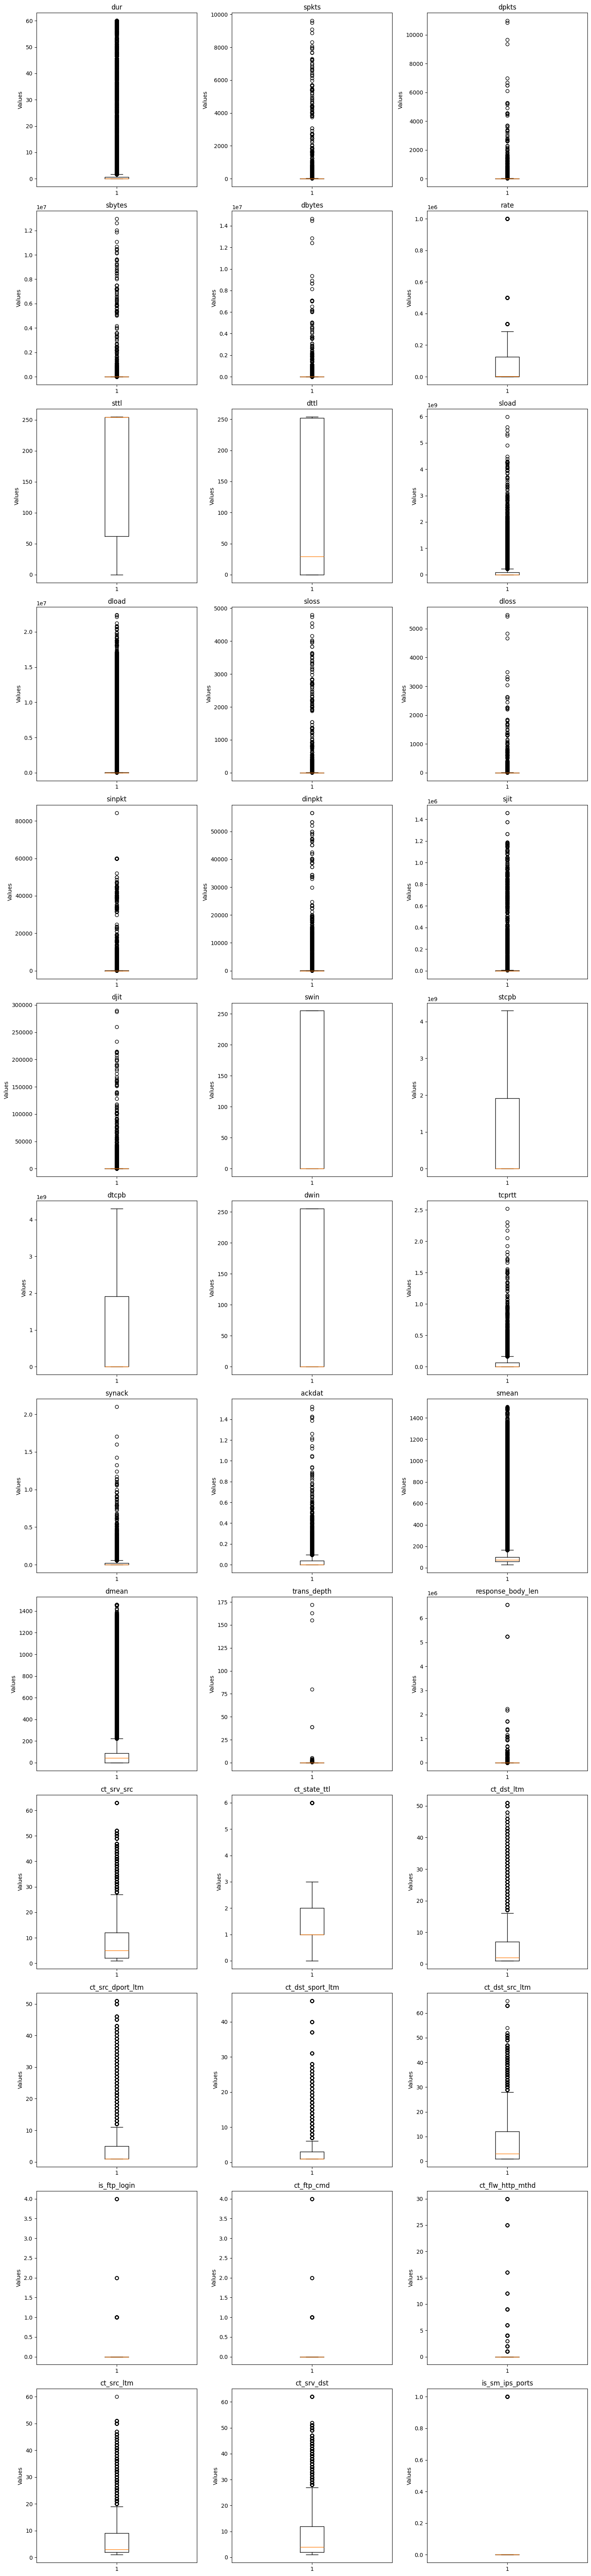

In [134]:
n = len(num_cols)
n_cols = 3 
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

if n_rows > 1 or n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

for i, col in enumerate(num_cols):
    if i < len(axes):
        axes[i].boxplot(train_df[col])
        axes[i].set_title(col)
        axes[i].set_ylabel('Values')

for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

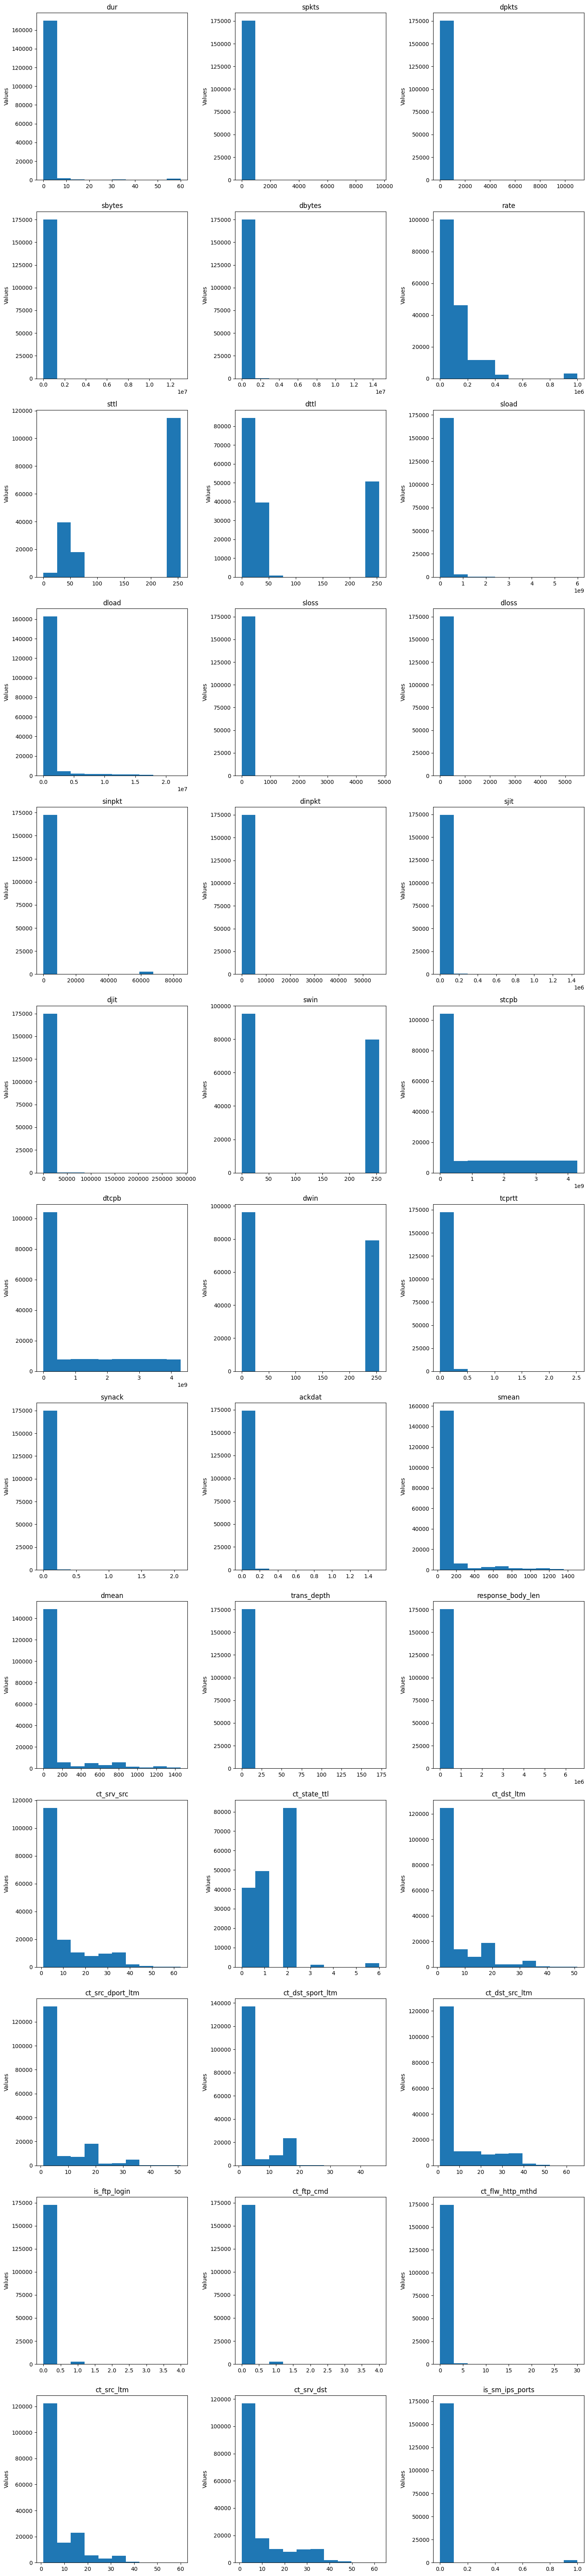

In [135]:
n = len(num_cols)
n_cols = 3 
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

if n_rows > 1 or n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

for i, col in enumerate(num_cols):
    if i < len(axes):
        axes[i].hist(train_df[col])
        axes[i].set_title(col)
        axes[i].set_ylabel('Values')

for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

heavy class imbalance in all, right tails, outliers present

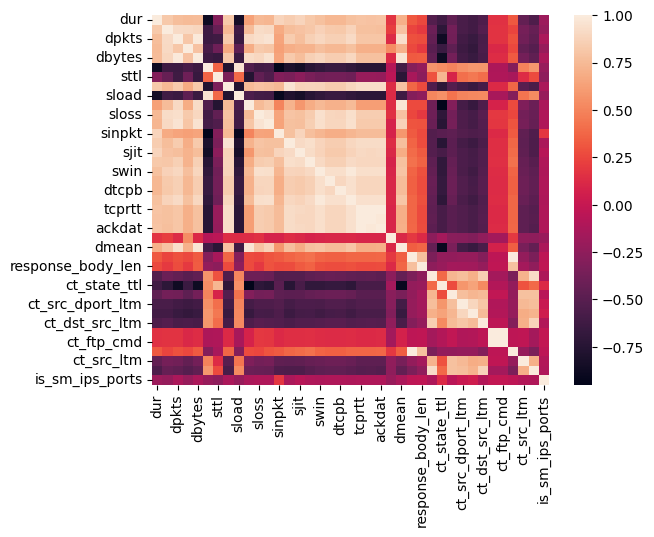

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
dur,1.000000,0.821227,0.768716,0.751776,0.756663,-0.878607,-0.308375,0.818093,-0.843464,0.626905,...,-0.469445,-0.575185,-0.613127,-0.553023,0.156362,0.156362,0.318531,-0.454352,-0.549296,-0.192961
spkts,0.821227,1.000000,0.910312,0.901268,0.887752,-0.633582,-0.437480,0.748341,-0.619482,0.758160,...,-0.377132,-0.573132,-0.609922,-0.521446,0.162705,0.162705,0.245476,-0.370372,-0.436723,-0.222844
dpkts,0.768716,0.910312,1.000000,0.811971,0.989853,-0.638889,-0.630129,0.831565,-0.648749,0.905469,...,-0.381125,-0.609387,-0.659183,-0.576230,0.169384,0.169384,0.286882,-0.383949,-0.469458,-0.120801
sbytes,0.751776,0.901268,0.811971,1.000000,0.791584,-0.580769,-0.394910,0.678313,-0.470815,0.684038,...,-0.472880,-0.630632,-0.684698,-0.566761,0.111726,0.111726,0.255443,-0.449782,-0.509370,-0.216513
dbytes,0.756663,0.887752,0.989853,0.791584,1.000000,-0.634919,-0.661841,0.822699,-0.650389,0.922864,...,-0.373400,-0.613898,-0.659665,-0.578084,0.135172,0.135172,0.327776,-0.378203,-0.469037,-0.120727
rate,-0.878607,-0.633582,-0.638889,-0.580769,-0.634919,1.000000,0.362076,-0.775301,0.960351,-0.534157,...,0.503755,0.554989,0.586754,0.573807,-0.116821,-0.116821,-0.302673,0.496199,0.586329,-0.215340
sttl,-0.308375,-0.437480,-0.630129,-0.394910,-0.661841,0.362076,1.000000,-0.333361,0.389625,-0.765411,...,0.091453,0.407528,0.450252,0.400892,-0.110787,-0.110787,-0.139532,0.138366,0.263597,-0.255586
dttl,0.818093,0.748341,0.831565,0.678313,0.822699,-0.775301,-0.333361,1.000000,-0.771263,0.753277,...,-0.522525,-0.602678,-0.655640,-0.588248,0.122915,0.122915,0.374728,-0.504901,-0.570207,-0.123080
sload,-0.843464,-0.619482,-0.648749,-0.470815,-0.650389,0.960351,0.389625,-0.771263,1.000000,-0.558996,...,0.427520,0.497892,0.517045,0.524415,-0.137563,-0.137563,-0.302358,0.430718,0.526581,-0.215073
dload,0.626905,0.758160,0.905469,0.684038,0.922864,-0.534157,-0.765411,0.753277,-0.558996,1.000000,...,-0.304806,-0.596642,-0.663838,-0.552315,0.079421,0.079421,0.266471,-0.320064,-0.409442,-0.120684


In [136]:
corr_table = train_df[num_cols].corr(method='spearman')
heatmap = sns.heatmap(corr_table)
plt.show()
corr_table

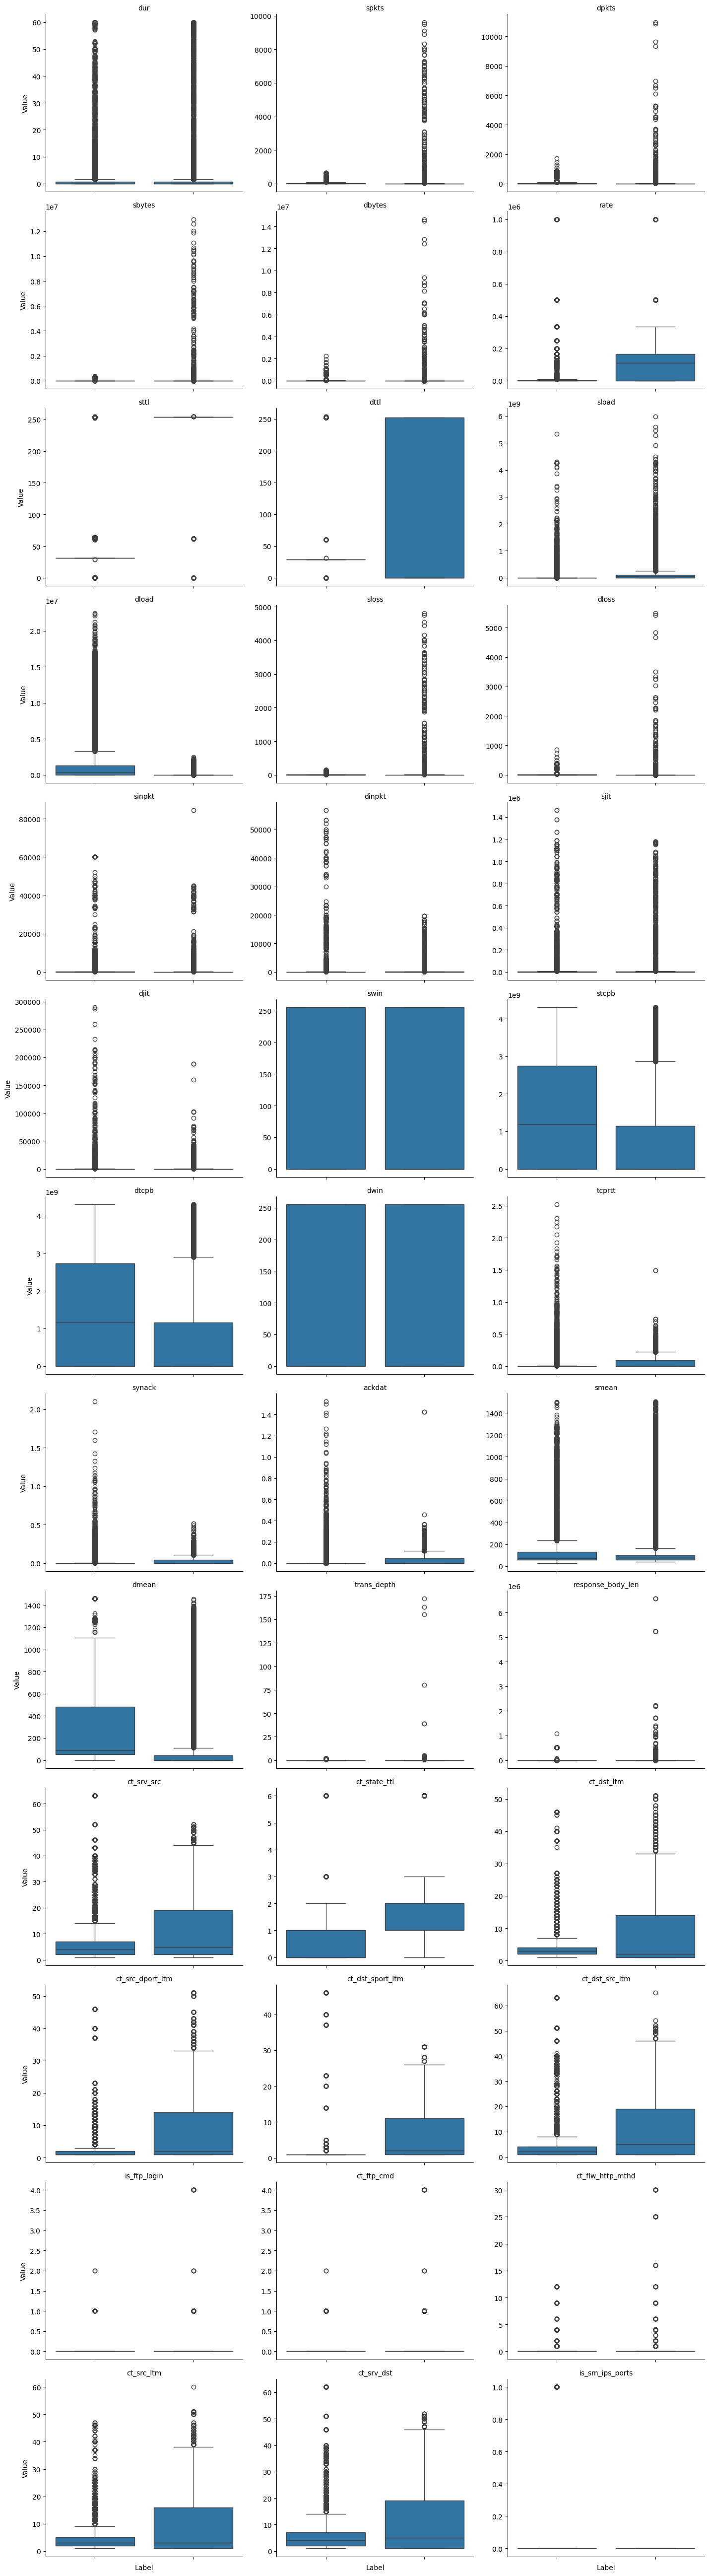

In [137]:
# Melt the DataFrame for seaborn
melted_df = pd.melt(train_df, 
                    id_vars=['label'], 
                    value_vars=num_cols,
                    var_name='feature', 
                    value_name='value')

# Create a FacetGrid
g = sns.FacetGrid(melted_df, col='feature', col_wrap=3, 
                  height=4, aspect=1.2, sharey=False)
g.map_dataframe(sns.boxplot, x='label', y='value')
g.set_titles("{col_name}")
g.set_axis_labels("Label", "Value")
g.set_xticklabels(rotation=45)

plt.tight_layout()
plt.show()

for label = 0, there are comparatively more outliers

In [138]:
train_df.isna().sum().sort_values(ascending=False)

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

cleaned already

In [139]:
train_df = train_df.drop(columns=['id', 'attack_cat'])
test_df = test_df.drop(columns=['id', 'attack_cat'])

In [140]:
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

In [141]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()


In [142]:
from catboost import CatBoostClassifier

kitty = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=50,
    verbose=50,
    class_weights=[1,3]
)

kitty.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.8596608	best: 0.8596608 (0)	total: 399ms	remaining: 3m 19s
50:	test: 0.9778021	best: 0.9778021 (50)	total: 21.8s	remaining: 3m 11s
100:	test: 0.9807920	best: 0.9808629 (96)	total: 43.2s	remaining: 2m 50s
150:	test: 0.9819387	best: 0.9819387 (150)	total: 1m 4s	remaining: 2m 28s
200:	test: 0.9824795	best: 0.9824795 (200)	total: 1m 25s	remaining: 2m 7s
250:	test: 0.9828423	best: 0.9828471 (247)	total: 1m 49s	remaining: 1m 48s
300:	test: 0.9829489	best: 0.9829518 (299)	total: 2m 13s	remaining: 1m 28s
350:	test: 0.9833135	best: 0.9833164 (349)	total: 2m 35s	remaining: 1m 6s
400:	test: 0.9835169	best: 0.9835226 (399)	total: 2m 57s	remaining: 43.8s
450:	test: 0.9836649	best: 0.9836649 (450)	total: 3m 19s	remaining: 21.7s
499:	test: 0.9836621	best: 0.9836683 (451)	total: 3m 43s	remaining: 0us

bestTest = 0.9836683248
bestIteration = 451

Shrink model to first 452 iterations.


In [143]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

y_test_proba = kitty.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba > 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


ROC-AUC: 0.9836683248036707
[[22056 14944]
 [   57 45275]]
              precision    recall  f1-score   support

           0       1.00      0.60      0.75     37000
           1       0.75      1.00      0.86     45332

    accuracy                           0.82     82332
   macro avg       0.87      0.80      0.80     82332
weighted avg       0.86      0.82      0.81     82332



In [144]:
thresholds = np.linspace(0.1, 0.9, 17)

for t in thresholds:
    preds = (y_test_proba > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    print(f"t={t:.2f} | FPR={fpr:.3f} | FNR={fnr:.4f}")


t=0.10 | FPR=0.425 | FNR=0.0000
t=0.15 | FPR=0.424 | FNR=0.0000
t=0.20 | FPR=0.424 | FNR=0.0000
t=0.25 | FPR=0.422 | FNR=0.0000
t=0.30 | FPR=0.422 | FNR=0.0000
t=0.35 | FPR=0.421 | FNR=0.0002
t=0.40 | FPR=0.418 | FNR=0.0005
t=0.45 | FPR=0.413 | FNR=0.0008
t=0.50 | FPR=0.404 | FNR=0.0013
t=0.55 | FPR=0.389 | FNR=0.0020
t=0.60 | FPR=0.367 | FNR=0.0033
t=0.65 | FPR=0.339 | FNR=0.0054
t=0.70 | FPR=0.304 | FNR=0.0089
t=0.75 | FPR=0.259 | FNR=0.0143
t=0.80 | FPR=0.206 | FNR=0.0240
t=0.85 | FPR=0.156 | FNR=0.0370
t=0.90 | FPR=0.106 | FNR=0.0577


In [151]:
y_test_proba = kitty.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba>0.75).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


ROC-AUC: 0.9836683248036707
[[27416  9584]
 [  647 44685]]
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     37000
           1       0.82      0.99      0.90     45332

    accuracy                           0.88     82332
   macro avg       0.90      0.86      0.87     82332
weighted avg       0.89      0.88      0.87     82332

